VGG16 Feature map extraction

In [1]:
from tensorflow.keras.applications import VGG16

In [2]:
base_model = VGG16(weights='imagenet')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [4]:
from tensorflow.keras.models import Model

In [5]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer('block5_pool').output)

In [6]:
from tensorflow.keras.preprocessing import image

In [7]:
img_dir='/content/drive/MyDrive/ROCo/test/radiology/images'

In [8]:
import cv2
import numpy as np
import os

In [10]:
image_files=[f for f in os.listdir(img_dir) if f.endswith(".jpg")]

In [18]:
img_path=os.path.join(img_dir,image_files[0])

In [19]:
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array=image.img_to_array(img)
    img_array=np.expand_dims(img_array,axis=0)
    img_array=preprocess_input(img_array)
    return img_array

In [20]:
img=image.load_img(img_path,target_size=(224,224))

In [21]:
img_array=image.img_to_array(img)
img_array

array([[[11., 11., 11.],
        [ 3.,  3.,  3.],
        [ 5.,  5.,  5.],
        ...,
        [ 2.,  2.,  2.],
        [ 3.,  3.,  3.],
        [11., 11., 11.]],

       [[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[ 3.,  3.,  3.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 1.,  1.,  1.],
        [ 2.,  2.,  2.],
        [ 7.,  7.,  7.]],

       ...,

       [[ 2.,  2.,  2.],
        [ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[ 5.,  5.,  5.],
        [ 4.,  4.,  4.],
        [ 3.,  3.,  3.],
        ...,
        [ 3.,  3.,  3.],
        [ 3.,  3.,  3.],
        [ 5.,  5.,  5.]]

In [24]:
img_array=np.expand_dims(img_array,axis=0)
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 958ms/step


In [25]:
n_features=feature_map.shape[-1]
n_features

512

In [26]:
size=feature_map.shape[1]

In [27]:
from PIL import Image

In [28]:
img=Image.open(img_path)

In [29]:
img.size

(693, 505)

In [30]:
display_grid=np.zeros((size,size*n_features))
display_grid

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [33]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [34]:
scale=20./n_features

In [35]:
import matplotlib.pyplot as plt

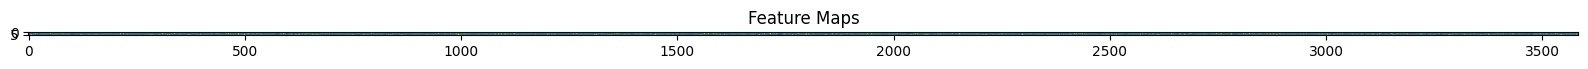

In [36]:
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect='auto')

VGG19 feature map extraction

In [48]:
from tensorflow.keras.applications import VGG19

In [49]:
base_model = VGG19(weights='imagenet')

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [50]:
from tensorflow.keras.models import Model

In [51]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer('block5_pool').output)

In [52]:
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array=image.img_to_array(img)
    img_array=np.expand_dims(img_array,axis=0)
    img_array=preprocess_input(img_array)
    return img_array

In [53]:
img=image.load_img(img_path,target_size=(224,224))

In [54]:
img_array=image.img_to_array(img)
img_array

array([[[11., 11., 11.],
        [ 3.,  3.,  3.],
        [ 5.,  5.,  5.],
        ...,
        [ 2.,  2.,  2.],
        [ 3.,  3.,  3.],
        [11., 11., 11.]],

       [[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[ 3.,  3.,  3.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 1.,  1.,  1.],
        [ 2.,  2.,  2.],
        [ 7.,  7.,  7.]],

       ...,

       [[ 2.,  2.,  2.],
        [ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[ 5.,  5.,  5.],
        [ 4.,  4.,  4.],
        [ 3.,  3.,  3.],
        ...,
        [ 3.,  3.,  3.],
        [ 3.,  3.,  3.],
        [ 5.,  5.,  5.]]

In [55]:
img_array=np.expand_dims(img_array,axis=0)
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [56]:
n_features=feature_map.shape[-1]
n_features

512

In [57]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [58]:
scale=20./n_features

In [59]:
import matplotlib.pyplot as plt

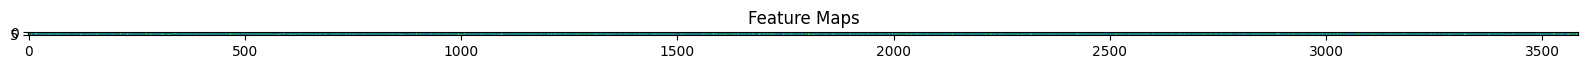

In [60]:
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect='auto')

ResNet

In [37]:
import tensorflow as tf
import numpy as np

In [38]:
base_model=tf.keras.applications.ResNet50(weights='imagenet',include_top=False)
base_model.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [39]:
img=tf.keras.preprocessing.image.load_img(img_path,target_size=(224,224))

In [40]:
img_array=tf.keras.preprocessing.image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)

In [41]:
img_array.shape

(1, 224, 224, 3)

In [43]:
img_array=tf.keras.applications.resnet.preprocess_input(img_array)
img_array.shape

(1, 224, 224, 3)

In [44]:
img_array

array([[[[ -92.939, -105.779, -112.68 ],
         [-100.939, -113.779, -120.68 ],
         [ -98.939, -111.779, -118.68 ],
         ...,
         [-101.939, -114.779, -121.68 ],
         [-100.939, -113.779, -120.68 ],
         [ -92.939, -105.779, -112.68 ]],

        [[-102.939, -115.779, -122.68 ],
         [-102.939, -115.779, -122.68 ],
         [-102.939, -115.779, -122.68 ],
         ...,
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ]],

        [[-100.939, -113.779, -120.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-102.939, -115.779, -122.68 ],
         [-101.939, -114.779, -121.68 ],
         [ -96.939, -109.779, -116.68 ]],

        ...,

        [[-101.939, -114.779, -121.68 ],
         [-102.939, -115.779, -122.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-103.939, -116.779, -123.68 ],
         [-103.939, -1

In [45]:
feature_map=base_model(img_array)

In [46]:
feature_map

<tf.Tensor: shape=(1, 7, 7, 2048), dtype=float32, numpy=
array([[[[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         ...,
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ]],

        [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.14303786,  0.        ],
         [ 0.08277822,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.  

In [47]:
feature_map.shape

TensorShape([1, 7, 7, 2048])